# RatesFactor: Treasury Curve Risk, Hedging, and VaR Prototype

## Goal: build a public-data fixed-income risk prototype using Treasury curve data, PCA factor risk, DV01 hedging, scenario analysis, and VaR.

In [363]:
import requests
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import CubicSpline
from scipy.stats import norm
from sklearn.decomposition import PCA

In [365]:
api_key = "YOUR_FRED_API_KEY"
history_years = 5
series = series = [
        (1 / 12, "DGS1MO"),
        (3 / 12, "DGS3MO"),
        (6 / 12, "DGS6MO"),
        (1.0, "DGS1"),
        (2.0, "DGS2"),
        (3.0, "DGS3"),
        (5.0, "DGS5"),
        (7.0, "DGS7"),
        (10.0, "DGS10"),
        (20.0, "DGS20"),
        (30.0, "DGS30")
    ]

In [618]:
# hedge_instruments = pd.DataFrame({
#     "bond": ["2Y Hedge Note", "5Y Hedge Note", "10Y Hedge Note", "30Y Hedge Bond"],
#     "face_value": [1_000_000, 1_000_000, 1_000_000, 1_000_000],
#     "coupon": [0.04, 0.04, 0.04, 0.04],
#     "maturity": [2, 5, 10, 30],
#     "frequency": [2, 2, 2, 2],
#     "positions": [1, 1, 1, 1]
# })
hedge_instruments = pd.DataFrame({
    "bond": [
        "6M Treasury Bill Hedge",
        "2Y Treasury Note Hedge",
    ],
    "face_value": [
        1_000_000,
        1_000_000,
    ],
    "coupon": [
        0.00,
        0.04,
    ],
    "maturity": [
        0.50,
        2.00,
    ],
    "frequency": [
        1,
        2,
    ],
    "positions": [
        1,
        1,
    ],
})
toy_portfolio = pd.DataFrame({
    "bond": ["2Y Note", "5Y Note", "10Y Note", "30Y Bond"],
    "face_value": [2_500_000, 2_500_000, 2_500_000, 2_500_000],
    "coupon": [0.040, 0.042, 0.045, 0.047],
    "maturity": [2, 5, 10, 30],
    "frequency": [2, 2, 2, 2],
    "positions": [1, 1, 1, 1]
})

# cost_bps = np.array([0.25, 0.35, 0.50, 0.75])
cost_bps = np.array([0.25, 0.35])

shock_bps = np.array([10, 10, 12, 15, 18, 22, 28, 32, 38, 45, 50]) # Bear Steepener

lookback = 252

day_count = "ACT/365.25"

In [620]:
def load_tlt_holdings_csv(path, as_of_date, target_notional=10_000_000):
    raw = pd.read_csv(path, skiprows=9)

    tlt = raw.copy()

    # Keep actual Treasury holdings only
    tlt = tlt[
        (tlt["Name"] == "TREASURY BOND")
        & (tlt["Sector"] == "Treasuries")
        & (tlt["Asset Class"] == "Fixed Income")
    ].copy()

    tlt["face_value"] = (
        tlt["Par Value"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    tlt["coupon"] = pd.to_numeric(tlt["Coupon (%)"], errors="coerce") / 100
    tlt["maturity_date"] = pd.to_datetime(tlt["Maturity"], errors="coerce")

    as_of_date = pd.Timestamp(as_of_date)

    tlt["maturity"] = (
        tlt["maturity_date"] - as_of_date
    ).dt.days / 365.25

    tlt = tlt.dropna(subset=["face_value", "coupon", "maturity"])
    tlt = tlt[tlt["maturity"] > 0].copy()

    if target_notional is not None:
        scale = target_notional / tlt["face_value"].sum()
        tlt["face_value"] = tlt["face_value"] * scale

    tlt_portfolio = pd.DataFrame({
        "bond": tlt["Name"] + " " + tlt["Coupon (%)"].astype(str) + "% " + tlt["Maturity"].astype(str),
        "face_value": tlt["face_value"],
        "coupon": tlt["coupon"],
        "maturity": tlt["maturity"],
        "frequency": 2,
        "positions": 1,
    }).reset_index(drop=True)

    return tlt_portfolio

In [622]:
def load_standard_holdings(path, as_of_date, target_notional=10_000_000):
    raw_df = pd.read_excel(path)
    holdings_df = raw_df.loc[:, ['Description', 'Coupon (%)', 'Par Value', 'Maturity', 'Frequency']]

    holdings_df["face_value"] = (
        holdings_df["Par Value"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )
    
    holdings_df['coupon'] = pd.to_numeric(holdings_df['Coupon (%)'])/100
    holdings_df['maturity_date'] = pd.to_datetime(holdings_df["Maturity"], errors="coerce")

    as_of_date = pd.Timestamp(as_of_date)
    holdings_df['maturity'] = (holdings_df['maturity_date'] - as_of_date).dt.days/365.25

    holdings_df = holdings_df.dropna(subset=["face_value", "coupon", "maturity"])
    holdings_df = holdings_df[holdings_df["maturity"] > 0].copy()
    
    if target_notional is not None:
        scale = target_notional/holdings_df['face_value'].sum()
        holdings_df['face_value'] *= scale

    holdings_portfolio = pd.DataFrame({
        "bond": holdings_df["Description"] + " " + holdings_df["Coupon (%)"].astype(str) + \
        " " + holdings_df["Maturity"].astype(str),
        "face_value": holdings_df["face_value"],
        "coupon": holdings_df["coupon"],
        "maturity": holdings_df["maturity"],
        "frequency": holdings_df["Frequency"],
        "positions": 1,
    }).reset_index(drop=True)

    return holdings_portfolio

In [624]:
def load_portfolio(source_type, path = None, as_of_date = None, target_notional = 10_000_000):
    as_of_date = pd.Timestamp(as_of_date)
    if source_type == "toy":
        return as_of_date, toy_portfolio.copy()
    elif source_type == "tlt":
        return as_of_date, load_tlt_holdings_csv(path, as_of_date, target_notional)
    elif source_type == "standard":
        return as_of_date, load_standard_holdings(path, as_of_date, target_notional)
    else:
        raise ValueError("source_type must be 'toy', 'tlt', or 'standard'")

In [626]:
path = "path/to/Standard Portfolio Template.xlsx"
holdings_as_of_date, portfolio = load_portfolio("standard", path, as_of_date = "07/12/2026")
display(portfolio.head())

end_date = holdings_as_of_date
start_date = end_date - pd.DateOffset(years=history_years)

print(start_date)
print(end_date)

,bond,face_value,coupon,maturity,frequency,positions
0,US TREASURY N/B 3.5 2026-09-30,2.216404e+06,0.0350,0.219028,2,1
1,US TREASURY N/B 4.25 2026-11-30,1.966149e+06,0.0425,0.386037,2,1
2,US TREASURY N/B 4.13 2027-02-15,1.945929e+06,0.0413,0.596851,2,1
3,US TREASURY N/B 3.88 2027-03-31,1.959197e+06,0.0388,0.717317,2,1
4,US TREASURY N/B 0.5 2027-05-31,1.912321e+06,0.0050,0.884326,2,1


2021-07-12 00:00:00
2026-07-12 00:00:00


In [628]:
# Codex Generated sample scenarios
preset_scenarios = {
    # Broad curve moves
    "parallel_up_25bp": np.array([25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25]),
    "parallel_down_25bp": np.array([-25, -25, -25, -25, -25, -25, -25, -25, -25, -25, -25]),

    # Slope shocks
    "bear_steepener": np.array([5, 5, 8, 10, 15, 20, 25, 30, 35, 45, 50]),
    "bull_steepener": np.array([-35, -35, -30, -25, -20, -15, -10, -5, 0, 5, 10]),
    "bear_flattener": np.array([50, 45, 40, 35, 30, 25, 18, 12, 8, 5, 3]),
    "bull_flattener": np.array([-5, -8, -12, -18, -25, -30, -35, -40, -45, -50, -55]),

    # Curve shape / curvature shocks
    "belly_selloff": np.array([5, 8, 12, 20, 35, 45, 50, 45, 30, 15, 10]),
    "belly_rally": np.array([-5, -8, -12, -20, -35, -45, -50, -45, -30, -15, -10]),

    # Front-end / Fed-sensitive shocks
    "front_end_selloff": np.array([60, 55, 50, 45, 35, 25, 15, 10, 5, 3, 2]),
    "front_end_rally": np.array([-60, -55, -50, -45, -35, -25, -15, -10, -5, -3, -2]),

    # Long-end / term-premium shocks
    "long_end_selloff": np.array([2, 3, 5, 8, 10, 12, 18, 25, 35, 50, 60]),
    "long_end_rally": np.array([-2, -3, -5, -8, -10, -12, -18, -25, -35, -50, -60]),

    # Stress scenarios
    "inflation_reacceleration": np.array([35, 40, 45, 50, 55, 60, 65, 65, 60, 55, 50]),
    "growth_scare": np.array([-40, -45, -50, -55, -55, -50, -45, -40, -35, -25, -20]),
    "liquidity_stress_long_end": np.array([10, 12, 15, 20, 25, 30, 40, 50, 65, 85, 100]),
}

# Data Pull

In [631]:
def fetch_fred_rates(series_id, api_key, start_date, end_date):
    # date should be in yyyy-mm-dd format
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "observation_start": start_date,
        "observation_end": end_date
    }

    response = requests.get(url, params)
    df = pd.DataFrame.from_dict(response.json()['observations'])
    df.drop(columns = ['realtime_start', 'realtime_end'], inplace = True)
    df.dropna(axis = 0, inplace = True)
    df = df[df['value'] != '.']
    df.set_index('date', inplace = True)
    df.index = pd.to_datetime(df.index)
    df['value'] = df['value'].astype(float)
    return df

In [633]:
def fetch_treasury_rates(series, api_key, start_date, end_date):
    # date should be in yyyy-mm-dd format
    rates = pd.DataFrame()
    for t, s_id in series:
        r = fetch_fred_rates(s_id, api_key, start_date, end_date)
        r.rename(columns = {"value": t}, inplace = True)
        rates = pd.concat([rates, r], axis = 1)
    rates.sort_index(inplace = True)
    rates.dropna(inplace = True)
    return rates

In [635]:
class RatesData:
    def __init__(self, rates_pct):
        self.rates_pct = rates_pct
        self.rates_pct.index = pd.to_datetime(rates_pct.index).normalize()
        self.rates_decimal = self.rates_pct/100
        
        self.dates = np.array(rates_pct.index)
        self.tenors = np.array(rates_pct.columns)
        self.latest_date = self.dates[-1]

        self.daily_changes_bp = self.rates_pct.diff().dropna()*100

    def get_curve(self, date, units = 'pct'):
        if date == None:
            date = self.latest_date

        if date not in self.dates:
            raise ValueError("Invalid Date")
            
        if units == "decimal":
            return self.rates_decimal.loc[date]
        elif units == "pct":
            return self.rates_pct.loc[date]
        else:
            raise ValueError("Invalid unit")

        

In [637]:
rates_pct_data = fetch_treasury_rates(series, api_key, 
                 start_date.strftime("%Y-%m-%d"), end_date.strftime("%Y-%m-%d"))
rates_data = RatesData(rates_pct_data)

print(rates_pct_data.head())
print(rates_pct_data.tail())

            0.083333   0.250000   0.500000   1.000000   2.000000   3.000000   \
date                                                                           
2021-07-12       0.05       0.05       0.06       0.08       0.23       0.43   
2021-07-13       0.05       0.05       0.06       0.08       0.26       0.47   
2021-07-14       0.06       0.06       0.05       0.08       0.23       0.44   
2021-07-15       0.05       0.05       0.05       0.07       0.23       0.43   
2021-07-16       0.05       0.05       0.05       0.08       0.25       0.43   

            5.000000   7.000000   10.000000  20.000000  30.000000  
date                                                               
2021-07-12       0.81       1.13       1.38       1.93       2.00  
2021-07-13       0.85       1.16       1.42       1.96       2.04  
2021-07-14       0.80       1.11       1.37       1.91       1.98  
2021-07-15       0.78       1.07       1.31       1.85       1.92  
2021-07-16       0.79       1.0

## Curve Diagnostics

In [639]:
def show_curve(rates_data, date):
    # Extracts (and plots) curve for a particular date
    curve = rates_data.get_curve(date)
    tenors = rates_data.tenors
    yields = np.array(curve)

    cs = CubicSpline(tenors, yields)

    tenor_grid = np.linspace(tenors.min(), tenors.max(), 300)
    fitted_yields = cs(tenor_grid)
            
    plt.figure(figsize=(8, 5))
    plt.plot(tenor_grid, fitted_yields, label="Cubic spline fit", linewidth=2)
    plt.scatter(tenors, yields, color="red", label="Observed DGS points", zorder=3)
    plt.xlabel("Maturity (years)")
    plt.ylabel("Yield (%)")
    plt.title(f"Treasury Yield Curve - {date}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [640]:
def compute_fwd(tenor_grid, yields_grid):
    ty = tenor_grid*yields_grid
    tenor_delta = tenor_grid[1] - tenor_grid[0]
    ty_delta = np.diff(ty)
    fwd_rate = ty_delta/tenor_delta
    
    plt.figure(figsize=(8, 5))
    plt.plot(tenor_grid[:-1], fwd_rate)
    plt.xlabel('Tenors')
    plt.ylabel('Fwd Rate (%)')
    dt = rates_data.latest_date
    plt.title('Forward Rate Curve')
    plt.show()

    return fwd_rate

In [641]:
def nss_loadings(tenors, tau1, tau2):
    X0 = np.ones(tenors.shape)
    X1 = (1 - np.exp(-1*tenors/tau1))/(tenors/tau1)
    X2 = (1 - np.exp(-1*tenors/tau1))/(tenors/tau1) - np.exp(-1*tenors/tau1)
    X3 = (1 - np.exp(-1*tenors/tau2))/(tenors/tau2) - np.exp(-1*tenors/tau2)
    # X Shape: (n_tenors, n_factors)
    X = np.column_stack([X0, X1, X2, X3]) # NSS Loading Matrix
    return X

def fit_nss_grid(tenors, yields, tau_min=0.2, tau_max=30, grid_size=100):
    g = np.linspace(np.log(0.2), np.log(30), 100)
    grid = itertools.product(g, g)
    rmse_min = np.inf
    beta_best = None
    tau_best = None
    for m1, m2 in grid:
        tau1, tau2 = np.exp(m1), np.exp(m2)
        # X Shape: (n_tenors, n_factors)
        X = nss_loadings(tenors, tau1, tau2) # NSS Loading Matrix
        
        beta = np.linalg.lstsq(X, yields, rcond=None)[0]
        fitted = X@beta
        rmse = np.sqrt(np.mean((yields - fitted)**2))
        
        if rmse < rmse_min:
            rmse_min = rmse
            beta_best = beta
            tau_best = np.array([tau1, tau2])
            
    return beta_best, tau_best, rmse_min

def nss_yield(tenors, beta, tau1, tau2):
    X = nss_loadings(tenors, tau1, tau2)
    fitted_yields = X@beta
    return fitted_yields

## Spline vs NSS Comparison

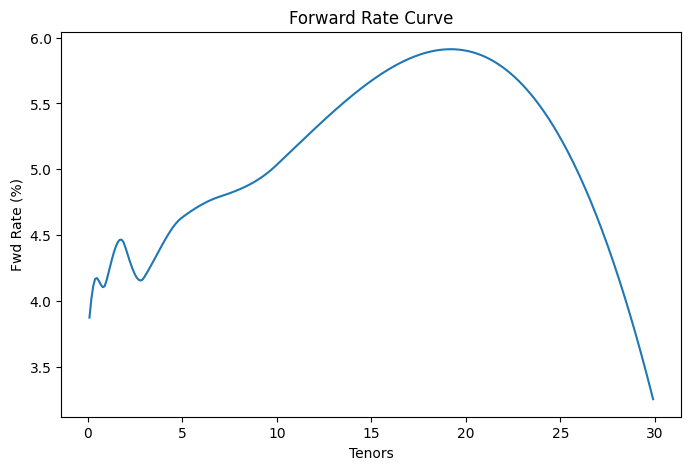

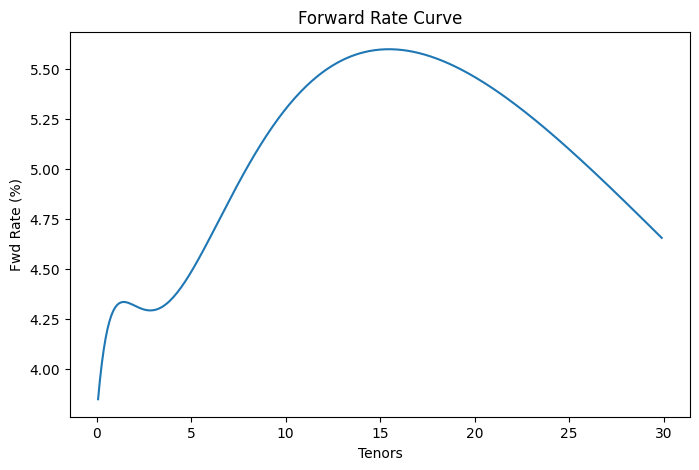

NSS beta: [ 1.62502745  2.06350039  2.92780009 10.80373955]
NSS tau: [ 1.36866559 15.53716928]
Spline RMSE: 0.000000% (0.00 bp)
NSS RMSE: 0.025929% (2.59 bp)

Spline forward min/max/range: 3.25% / 5.91% / 2.66%
NSS forward min/max/range: 3.85% / 5.60% / 1.75%
Spline forward turning points: 5
NSS forward turning points: 3


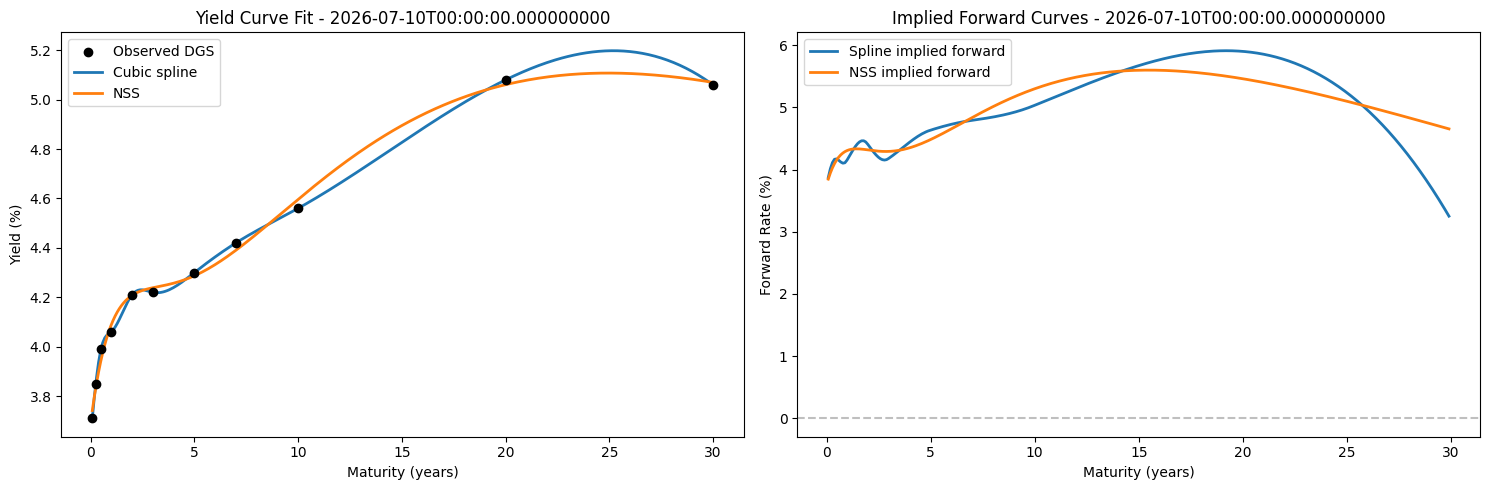

In [647]:
date = rates_data.latest_date

# Use percent yields for visualization
curve = rates_data.get_curve(date, units="pct")
tenors = rates_data.tenors
yields = curve.to_numpy(dtype=float)

# Fine grid
tenor_grid = np.linspace(tenors.min(), tenors.max(), 300)

# --- Cubic spline ---
cs = CubicSpline(tenors, yields)
spline_yields_grid = cs(tenor_grid)
spline_yields_at_nodes = cs(tenors)

spline_rmse = np.sqrt(np.mean((yields - spline_yields_at_nodes) ** 2))

# --- NSS ---
beta_best, tau_best, nss_rmse = fit_nss_grid(tenors, yields)

nss_yields_grid = nss_yield(
    tenor_grid,
    beta_best,
    tau_best[0],
    tau_best[1]
)

nss_yields_at_nodes = nss_yield(
    tenors,
    beta_best,
    tau_best[0],
    tau_best[1]
)

# If your fit_nss_grid does not return nss_rmse yet, uncomment:
# nss_rmse = np.sqrt(np.mean((yields - nss_yields_at_nodes) ** 2))

# --- Forward curves ---
spline_fwd = compute_fwd(tenor_grid, spline_yields_grid)
nss_fwd = compute_fwd(tenor_grid, nss_yields_grid)

# --- Diagnostics ---
def count_turning_points(x):
    return np.sum(np.diff(np.sign(np.diff(x))) != 0)

print("NSS beta:", beta_best)
print("NSS tau:", tau_best)
print(f"Spline RMSE: {spline_rmse:.6f}% ({spline_rmse * 100:.2f} bp)")
print(f"NSS RMSE: {nss_rmse:.6f}% ({nss_rmse * 100:.2f} bp)")
print()
print(f"Spline forward min/max/range: {spline_fwd.min():.2f}% / {spline_fwd.max():.2f}% / {(spline_fwd.max() - spline_fwd.min()):.2f}%")
print(f"NSS forward min/max/range: {nss_fwd.min():.2f}% / {nss_fwd.max():.2f}% / {(nss_fwd.max() - nss_fwd.min()):.2f}%")
print(f"Spline forward turning points: {count_turning_points(spline_fwd)}")
print(f"NSS forward turning points: {count_turning_points(nss_fwd)}")

# --- Plot yield fits ---
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(tenors, yields, color="black", label="Observed DGS", zorder=3)
ax[0].plot(tenor_grid, spline_yields_grid, label="Cubic spline", linewidth=2)
ax[0].plot(tenor_grid, nss_yields_grid, label="NSS", linewidth=2)

ax[0].set_title(f"Yield Curve Fit - {date}")
ax[0].set_xlabel("Maturity (years)")
ax[0].set_ylabel("Yield (%)")
ax[0].legend()

# --- Plot forward curves ---
ax[1].plot(tenor_grid[:-1], spline_fwd, label="Spline implied forward", linewidth=2)
ax[1].plot(tenor_grid[:-1], nss_fwd, label="NSS implied forward", linewidth=2)
ax[1].axhline(0, color="gray", linestyle="--", alpha=0.5)

ax[1].set_title(f"Implied Forward Curves - {date}")
ax[1].set_xlabel("Maturity (years)")
ax[1].set_ylabel("Forward Rate (%)")
ax[1].legend()

plt.tight_layout()
plt.show()

# PCA

In [650]:
def fit_pca(daily_changes_bp, n_components = 3):
    # PCA
    # daily_changes_bp = rates_data.daily_changes_bp
    pca = PCA(n_components = n_components)
    pca.fit(daily_changes_bp)
    return pca

In [652]:
def show_loadings(pca, rates_data):

    maturities = rates_data.tenors
    
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#2c3e50', '#e74c3c', '#3498db']
    labels = ['PC1 — Level', 'PC2 — Slope', 'PC3 — Curvature']
    
    for i in range(3):
        pct = pca.explained_variance_ratio_[i] * 100
        ax.plot(maturities, pca.components_[i], marker='o', linewidth=2.5,
                markersize=8, color=colors[i],
                label=f'{labels[i]} ({pct:.1f}%)')
    
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Maturity (years)')
    ax.set_ylabel('Loading')
    ax.set_title('Principal Component Loadings of Yield Curve Changes', fontweight='bold')
    ax.set_xticks(maturities)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [654]:
# Claude Generated
def decompose_move(pca, rates_data, date):
    change_curve = np.array(rates_data.daily_changes_bp.loc[date])
    maturities = rates_data.tenors
    
    scores = pca.transform(change_curve.reshape(1,-1))
    print(scores)
    
    pc_contribs = {}
    for i in range(3):
        pc_contribs["PC{0}".format(i+1)] = scores[0, i]*pca.components_[i]
    
    reconstructed_curve = pca.mean_ + sum(pc_contribs.values())
    residual = change_curve - reconstructed_curve

    
    pc1_move = pc_contribs["PC1"]
    pc2_move = pc_contribs["PC2"]
    pc3_move = pc_contribs["PC3"]
    residual_move = residual

    plt.figure(figsize=(10, 6))

    plt.plot(maturities, change_curve, marker='o', linewidth=3, label='Actual Move', color='black')
    plt.plot(maturities, reconstructed_curve, marker='o', linewidth=2, label='Reconstructed Curve', color = 'orange')
    plt.plot(maturities, pc1_move, marker='o', linewidth=2, label='PC1 Contribution')
    plt.plot(maturities, pc2_move, marker='o', linewidth=2, label='PC2 Contribution')
    plt.plot(maturities, pc3_move, marker='o', linewidth=2, label='PC3 Contribution')
    plt.plot(maturities, residual_move, marker='o', linewidth=2, linestyle='--', label='Residual')
    
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.xlabel('Maturity (years)')
    plt.ylabel('Yield Change (bp)')
    plt.title(f'PCA Decomposition of Treasury Curve Move - {date}')
    plt.xticks(maturities)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [656]:
def fit_rolling_pca(daily_changes_bp, lookback = 252, n_components=3):
    
    dates = np.array(daily_changes_bp.index)
    rolling_pca = {}
    
    for idx in range(lookback, len(daily_changes_bp)+1):
        window = daily_changes_bp.iloc[idx-lookback:idx]
        pca_window = fit_pca(window, n_components = n_components)
        date = pd.Timestamp(dates[idx-1])       
        rolling_pca[date] = {
            "pca": pca_window,
            "start_date": dates[idx-lookback],
            "end_date": dates[idx-1],
            "components": pca_window.components_,
            "explained_variance_ratio": pca_window.explained_variance_ratio_,
            "mean": pca_window.mean_
        }
        
    return rolling_pca

In [658]:
# Rolling PCA creation
rolling_pca = fit_rolling_pca(rates_data.daily_changes_bp)

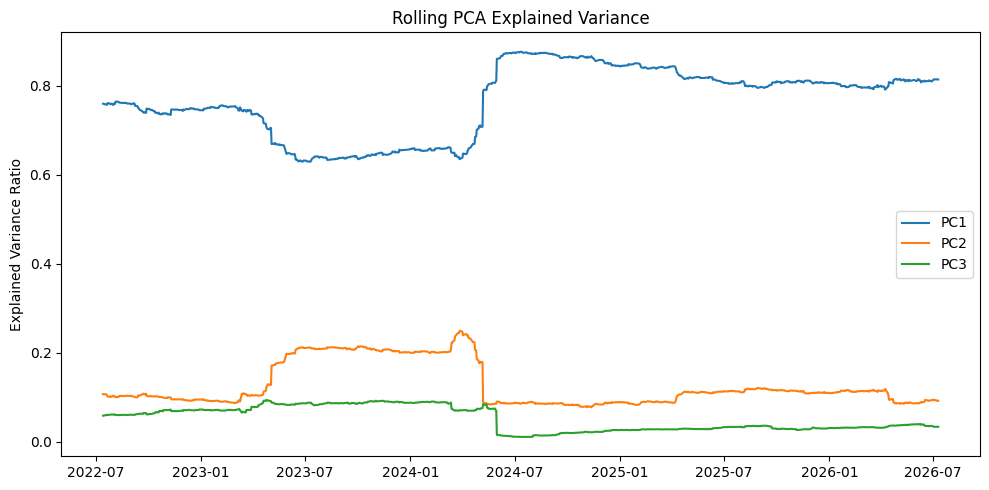

In [659]:
# Rolling Explained Variance Plot
rolling_dates = list(rolling_pca.keys())

explained_var_df = pd.DataFrame(
    [rolling_pca[d]["explained_variance_ratio"] for d in rolling_dates],
    index=rolling_dates,
    columns=["PC1", "PC2", "PC3"]
)

plt.figure(figsize=(10, 5))
plt.plot(explained_var_df.index, explained_var_df["PC1"], label="PC1")
plt.plot(explained_var_df.index, explained_var_df["PC2"], label="PC2")
plt.plot(explained_var_df.index, explained_var_df["PC3"], label="PC3")
plt.ylabel("Explained Variance Ratio")
plt.title("Rolling PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

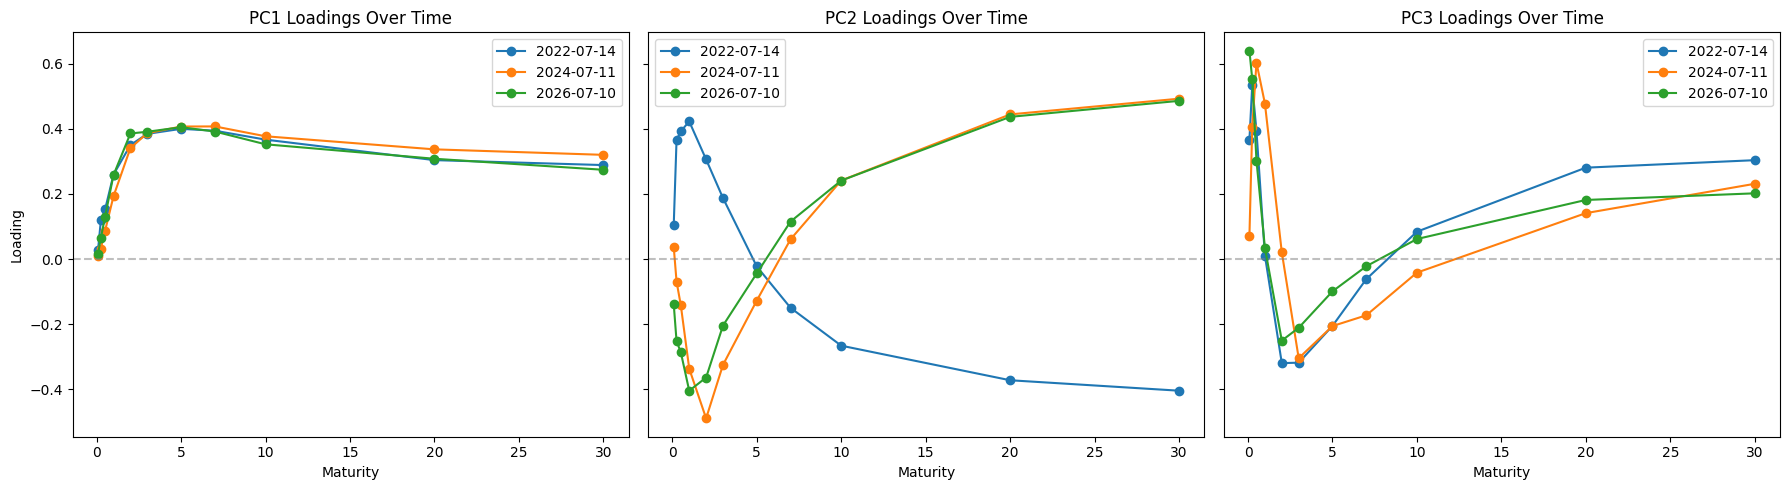

In [662]:
# Rolling Loading Stability Plot
sample_dates = [
    rolling_dates[0],
    rolling_dates[len(rolling_dates) // 2],
    rolling_dates[-1]
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for pc_idx, ax in enumerate(axes):
    for d in sample_dates:
        ax.plot(
            rates_data.tenors,
            rolling_pca[d]["components"][pc_idx],
            marker="o",
            label=str(pd.to_datetime(d).date())
        )

    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(f"PC{pc_idx + 1} Loadings Over Time")
    ax.set_xlabel("Maturity")
    ax.legend()

axes[0].set_ylabel("Loading")
plt.tight_layout()
plt.show()

In [664]:
# Static vs Latest Rolling PCA Summary
static_pca = fit_pca(rates_data.daily_changes_bp, n_components=3)

latest_rolling_date = rolling_dates[-1]
latest_rolling_pca = rolling_pca[latest_rolling_date]["pca"]

print("Static explained variance:", static_pca.explained_variance_ratio_)
print("Latest rolling explained variance:", latest_rolling_pca.explained_variance_ratio_)
print("Latest rolling PCA date:", latest_rolling_date)

Static explained variance: [0.73157987 0.103831   0.09544311]
Latest rolling explained variance: [0.81365926 0.09150376 0.03308122]
Latest rolling PCA date: 2026-07-10 00:00:00


# Pricing / DV01 / Hedging Helpers

In [667]:
# Bond Pricing Function (Simple) (Have implemented the improved bond pricing function in the actual python script)
def bond_pricer(face_value, c, T, rate_curve, cs, f):
    # rates curve must be in decimals
    pv = 0
    n = int(round(f*T))
    for i in range(n):
        t = float((i + 1)/f)
        if t in rate_curve.index:
            r = rate_curve[t]
        else:
            r = float(cs(t))
        
        cf = (c/f)*face_value
        if i == n - 1:
            cf += face_value
        dcf = cf/pow(1+r/f, i + 1)
        pv += dcf
    return pv

# def year_fraction(start_date, end_date, day_count = "ACT/365.25"):
#     days = (end_date - start_date).days

#     if day_count == "ACT/365.25":
#         return days/365.25
#     elif day_count == "ACT/365":
#         return days/365
#     elif day_count == "ACT/360":
#         return days/360
#     else:
#         raise ValueError("Day Counting Convention must be ACT/365.25, ACT/365 or ACT/360")

    
# # Bond Pricing Function (Improved)
# def bond_price(face_value, c, settlement_date, maturity_date, cs, f, day_count = "ACT/365.25"):
#     if 12 % f != 0:
#         raise ValueError("Frequency Must Divide 12")
    
#     pv = 0
#     months_step = 12//f # Coupon Period
#     i = 0
    
#     while maturity_date - pd.DateOffset(months = i*months_step) > settlement_date:
#         cf_date = maturity_date - pd.DateOffset(months = i*months_step)
#         t = year_fraction(settlement_date, cf_date, day_count)
#         cf = (c/f)*face_value
#         if i == 0:
#             cf += face_value
#         r = float(cs(t))
#         dcf = cf/pow(1 + r/f, f*t)
#         pv += dcf
#         i += 1

#     cf_date_next = maturity_date - pd.DateOffset(months = (i-1)*months_step)
#     cf_date_last = maturity_date - pd.DateOffset(months = i*months_step)
    
#     accrued_interest = 0
#     if cf_date_last < settlement_date < cf_date_next:
#         accrual_time_fraction = year_fraction(cf_date_last, settlement_date, day_count)
#         coupon_time_fraction = year_fraction(cf_date_last, cf_date_next, day_count)
#         accrued_interest = (accrual_time_fraction/coupon_time_fraction)*(c/f)*face_value
        
#     dirty_bond_price = pv
#     clean_bond_price = dirty_bond_price - accrued_interest 
    
#     return dirty_bond_price, clean_bond_price, accrued_interest

In [758]:
(t2 - t).month

AttributeError: 'Timedelta' object has no attribute 'month'

In [669]:
def portfolio_value(portfolio, rate_curve):

    cs = CubicSpline(
        rate_curve.index.astype(float).to_numpy(),
        rate_curve.to_numpy(dtype=float)
    )

    values = portfolio.apply(
        lambda row: row["positions"] * bond_pricer(
            row["face_value"],
            row["coupon"],
            row["maturity"],
            rate_curve,
            cs,
            row["frequency"]
        ),
        axis=1
    )

    return values.sum()

In [671]:
def bump_curve(rates_data, date, maturity, bump = 0.0001):
    # Bumps at a particular node/maturity
    rate_curve = rates_data.get_curve(date, "decimal")
    rate_curve_up = rate_curve.copy()
    rate_curve_down = rate_curve.copy()
    rate_curve_up.loc[maturity] += bump
    rate_curve_down.loc[maturity] -= bump
    return rate_curve_up, rate_curve_down

def parallel_bump_curve(rates_data, date, bump = 0.0001):
    # Bumps parallelly across the curve
    rate_curve = rates_data.get_curve(date, "decimal")
    rate_curve_up = rate_curve.copy()
    rate_curve_down = rate_curve.copy()
    rate_curve_up += bump
    rate_curve_down -= bump
    return rate_curve_up, rate_curve_down

In [673]:
def make_delta_ladder(portfolio, rates_data, date):
    maturities = rates_data.tenors
    
    delta_ladder = []
    
    for maturity in maturities:
        # Bumping rates for the chosen maturity
        rates_up, rates_down = bump_curve(rates_data, date, maturity)
        
        
        price_up = portfolio_value(portfolio, rates_up)
        price_down = portfolio_value(portfolio,rates_down)

        total_signed_key_rate_dv01 = (price_down - price_up)/2
        delta_ladder.append(total_signed_key_rate_dv01)

    return np.array(delta_ladder)

In [675]:
def pca_hedge(portfolio, hedge_instruments, rates_data, date, pca, n_components = 3):
    hedge_ladder = []
    date = pd.Timestamp(date)
    
    # Shape of portfolio_ladder = n_tenors (1d), row vector
    portfolio_ladder = make_delta_ladder(portfolio, rates_data, date)
    
    for i in range(len(hedge_instruments)):
                # Used iloc[[i]] instead of iloc[i] to preserve a one-row DataFrame.
                # make_delta_ladder expects a DataFrame because it applies pricing row-wise
                # with axis=1; iloc[i] would return a 1D Series and break that logic.
                hedge_instrument = hedge_instruments.iloc[[i]]
                instrument_ladder = make_delta_ladder(hedge_instrument, rates_data, date)
                hedge_ladder.append(instrument_ladder)
    
    # Shape of hedge_ladders: n_hedges x n_tenors           
    hedge_ladder = np.array(hedge_ladder)

    # Shape of v: n_components (for example 2 components for PC1-PC2 hedge) x n_tenors
    v = pca.components_[:n_components]

    A = v @ hedge_ladder.T
    y = -(v @ portfolio_ladder.T)
    
    # h1, h2, h3 = np.linalg.solve(A, y)

    # Use lstsq so the hedge construction works for square, overdetermined,
    # or underdetermined hedge systems. If exact factor neutralization is possible,
    # lstsq returns a solution; when multiple exact solutions exist, it returns the
    # minimum-norm hedge. If exact neutralization is not possible, it returns the
    # closest least-squares hedge.

    h, *_ = np.linalg.lstsq(A, y, rcond=None)

    return h

In [677]:
def build_hedged_portfolio(portfolio, hedge_instruments, hedge_weights):
    hedge_portfolio = hedge_instruments.copy()
    hedge_portfolio['positions'] = hedge_weights
    hedged_portfolio = pd.concat([
        portfolio,
        hedge_portfolio
    ], ignore_index=True)
    
    return hedged_portfolio

In [679]:
def calc_dv01(portfolio, rates_data, date):
    rates_up, rates_down = parallel_bump_curve(rates_data, date)
    
    price_up = portfolio_value(portfolio, rates_up)
    price_down = portfolio_value(portfolio,rates_down)

    total_signed_dv01 = (price_down - price_up)/2

    return total_signed_dv01
    

In [681]:
def dv01_hedge(portfolio, hedge_instrument, rates_data, date):
    dv01_portfolio = calc_dv01(portfolio, rates_data, date)
    dv01_hedge_instrument = calc_dv01(hedge_instrument, rates_data, date)
    return -1*dv01_portfolio/dv01_hedge_instrument

# Latest PCA Hedge Weights

In [685]:
latest_date = pd.Timestamp(rates_data.latest_date)
latest_pca = rolling_pca[latest_date]["pca"]
h = pca_hedge(portfolio, hedge_instruments, rates_data, latest_date, latest_pca)

## Hedge Backtest

In [689]:
def run_pca_hedge_backtest(portfolio, hedge_instruments, rates_data, rolling_pca, cost_bps, lookback=252):
    
    unhedged_portfolio = portfolio
    results = {}
    prev_h = None
    dates = np.array(list(rates_data.daily_changes_bp.index))
    
    
    for date, next_date in zip(dates[lookback-1:-1], dates[lookback:]):
        date = pd.Timestamp(date)
        next_date = pd.Timestamp(next_date)
        
        h = pca_hedge(portfolio, hedge_instruments, rates_data, date, rolling_pca[date]['pca'])

        hedged_portfolio = build_hedged_portfolio(portfolio, hedge_instruments, h)

        rate_curve_next = rates_data.get_curve(next_date, "decimal")
        rate_curve_curr = rates_data.get_curve(date, "decimal")
        
        # Hedged & Unhedged PnL
        unhedged_pnl = portfolio_value(unhedged_portfolio, rate_curve_next) \
                        - portfolio_value(unhedged_portfolio, rate_curve_curr)
    
        hedged_pnl = portfolio_value(hedged_portfolio, rate_curve_next) \
                    - portfolio_value(hedged_portfolio, rate_curve_curr)
    
        pnl_reduction = abs(unhedged_pnl) - abs(hedged_pnl)
    
        # Turonver calculation
        if prev_h is None:
            turnover = abs(h)
        else:
            turnover = abs(h - prev_h)
    
        prev_h = h.copy()
    
        # Transaction Cost Calculation
        traded_notional = turnover*hedge_instruments['face_value'].values
        transaction_cost = (cost_bps*traded_notional).sum()/10000
    
        # Net Hedged PnL
        net_hedged_pnl = hedged_pnl - transaction_cost
        net_pnl_reduction = abs(unhedged_pnl) - abs(net_hedged_pnl)
        
        results[date] = {
            'unhedged_pnl': unhedged_pnl, 'hedged_pnl': hedged_pnl, 
            'net_hedged_pnl': net_hedged_pnl,
            'pnl_reduction': pnl_reduction, 
            'net_pnl_reduction': net_pnl_reduction,
            'hedge_weights': h, 'turnover':turnover, 'transaction_cost': transaction_cost
        }
                     
    return results

,value
num_days,996.000000
avg_abs_unhedged_pnl,1190.605051
avg_abs_gross_hedged_pnl,903.389496
avg_abs_net_hedged_pnl,903.334464
unhedged_pnl_vol,1915.317038
gross_hedged_pnl_vol,1292.239230
net_hedged_pnl_vol,1292.240644
worst_unhedged_pnl,-11394.703100
worst_gross_hedged_pnl,-6539.461689
worst_net_hedged_pnl,-6539.621619


,unhedged_pnl,hedged_pnl,net_hedged_pnl,pnl_reduction,net_pnl_reduction,transaction_cost,h_6m,h_2y,turnover_6m,turnover_2y,...,abs_gross_hedged_pnl,abs_net_hedged_pnl,gross_hedge_helped,net_hedge_helped,gross_abs_pnl_reduction,net_abs_pnl_reduction,cum_unhedged_pnl,cum_gross_hedged_pnl,cum_net_hedged_pnl,cum_transaction_cost
date,,,,,,,,,,,,,,,,,,,,,
2022-07-14,440.635669,80.854024,49.303480,359.781645,391.332189,31.550544,0.0,-0.901444,0.0,0.901444,...,80.854024,49.303480,True,True,359.781645,391.332189,440.635669,80.854024,49.303480,31.550544
2022-07-15,-2511.502199,-2159.230294,-2159.262915,352.271906,352.239285,0.032621,0.0,-0.902376,0.0,0.000932,...,2159.230294,2159.262915,True,True,352.271906,352.239285,-2070.866530,-2078.376270,-2109.959435,31.583165
2022-07-18,-2078.146529,-690.913294,-690.969323,1387.233235,1387.177206,0.056029,0.0,-0.900775,0.0,0.001601,...,690.913294,690.969323,True,True,1387.233235,1387.177206,-4149.013059,-2769.289563,-2800.928758,31.639194
2022-07-19,581.724857,925.244647,925.055499,-343.519790,-343.330642,0.189147,0.0,-0.906180,0.0,0.005404,...,925.244647,925.055499,False,False,-343.519790,-343.330642,-3567.288202,-1844.044917,-1875.873258,31.828342
2022-07-20,2444.397807,-174.324089,-174.426475,2270.073718,2269.971332,0.102386,0.0,-0.909105,0.0,0.002925,...,174.324089,174.426475,True,True,2270.073718,2269.971332,-1122.890395,-2018.369006,-2050.299733,31.930727


Gross hedge reduced average absolute daily P&L by 24.12%.
Net hedge reduced average absolute daily P&L by 24.13% after transaction costs.
Gross hedge reduced daily P&L volatility by 32.53%.
Net hedge reduced daily P&L volatility by 32.53% after transaction costs.
Net hedge reduced absolute P&L on 60.94% of days.
Total transaction cost: $475.51.


(array([  1.,   1.,   1.,   1.,   1.,   1.,   0.,   0.,   4.,   3.,   4.,
          9.,   6.,  16.,  14.,  14.,  23.,  32.,  50.,  53., 100., 116.,
        146., 131.,  84.,  60.,  34.,  25.,  17.,  16.,  11.,   7.,   4.,
          2.,   4.,   2.,   1.,   1.,   0.,   1.]),
 array([-6539.62161919, -6243.53617312, -5947.45072704, -5651.36528097,
        -5355.27983489, -5059.19438882, -4763.10894274, -4467.02349667,
        -4170.93805059, -3874.85260452, -3578.76715844, -3282.68171237,
        -2986.59626629, -2690.51082022, -2394.42537414, -2098.33992807,
        -1802.25448199, -1506.16903591, -1210.08358984,  -913.99814376,
         -617.91269769,  -321.82725161,   -25.74180554,   270.34364054,
          566.42908661,   862.51453269,  1158.59997876,  1454.68542484,
         1750.77087091,  2046.85631699,  2342.94176306,  2639.02720914,
         2935.11265521,  3231.19810129,  3527.28354736,  3823.36899344,
         4119.45443951,  4415.53988559,  4711.62533166,  5007.71077774,
      

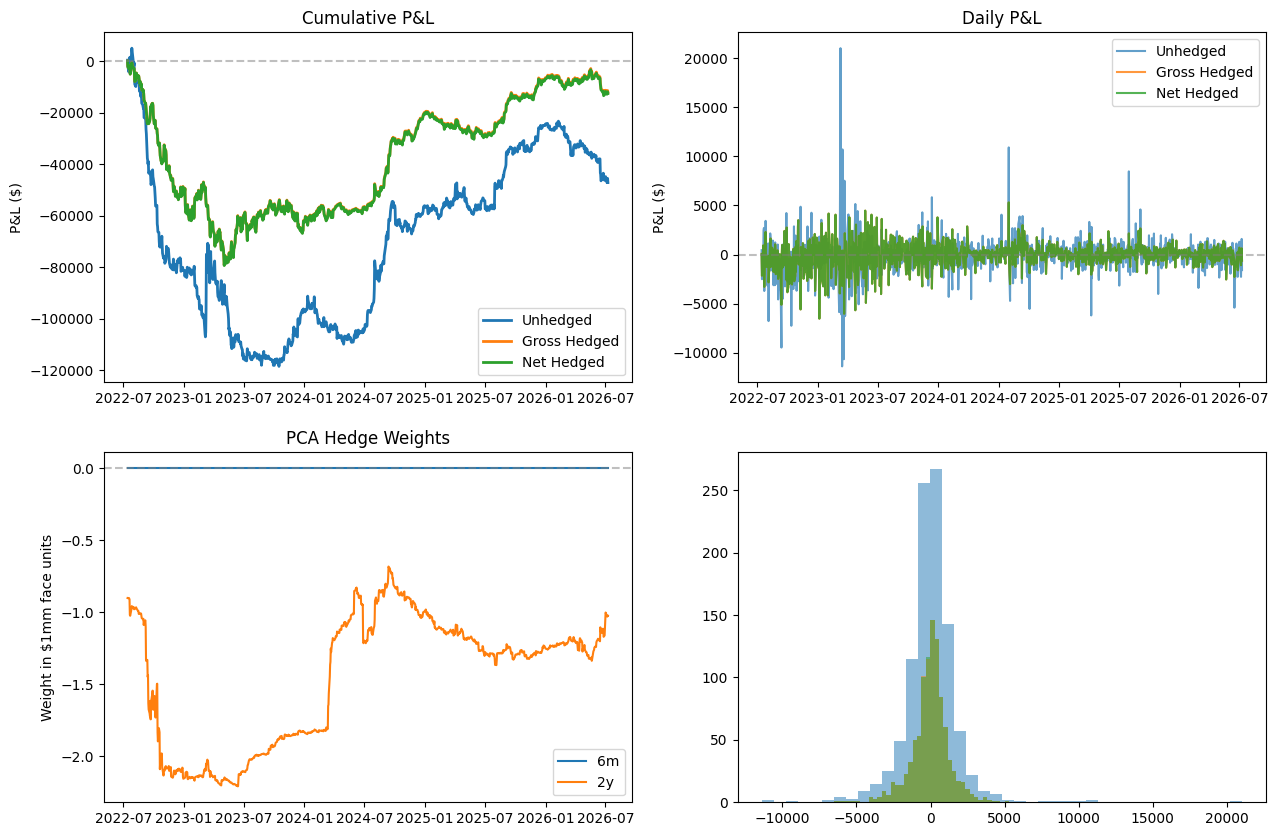

In [695]:
# =========================
# Multi-Day Hedge Backtest Reporting
# Gross vs Net Transaction-Cost-Aware P&L
# =========================

results = run_pca_hedge_backtest(
    portfolio,
    hedge_instruments,
    rates_data,
    rolling_pca,
    cost_bps,
    lookback
)

results_df = pd.DataFrame.from_dict(results, orient="index")
results_df.index = pd.to_datetime(results_df.index)
results_df = results_df.sort_index()
results_df.index.name = "date"


# =========================
# Dynamic hedge labels
# =========================

def make_hedge_label(row):
    if "bond" in row.index:
        label = str(row["bond"])
    else:
        label = f"{row['maturity']}Y"

    label = (
        label.lower()
        .replace("treasury", "")
        .replace("bill", "")
        .replace("note", "")
        .replace("bond", "")
        .replace("hedge", "")
        .replace(" ", "_")
        .replace("__", "_")
        .strip("_")
    )

    if label == "":
        label = f"{row['maturity']}y"

    return label


hedge_labels = [
    make_hedge_label(hedge_instruments.iloc[i])
    for i in range(len(hedge_instruments))
]

hedge_weight_cols = [f"h_{label}" for label in hedge_labels]
turnover_cols = [f"turnover_{label}" for label in hedge_labels]


# =========================
# Expand hedge weights
# =========================

hedge_weights_df = pd.DataFrame(
    results_df["hedge_weights"].to_list(),
    index=results_df.index,
    columns=hedge_weight_cols
)

results_df = pd.concat(
    [results_df.drop(columns=["hedge_weights"]), hedge_weights_df],
    axis=1
)


# =========================
# Expand turnover
# =========================

if "turnover" in results_df.columns:
    turnover_df = pd.DataFrame(
        results_df["turnover"].to_list(),
        index=results_df.index,
        columns=turnover_cols
    )

    results_df = pd.concat(
        [results_df.drop(columns=["turnover"]), turnover_df],
        axis=1
    )


# =========================
# Metrics
# =========================

results_df["abs_unhedged_pnl"] = results_df["unhedged_pnl"].abs()
results_df["abs_gross_hedged_pnl"] = results_df["hedged_pnl"].abs()
results_df["abs_net_hedged_pnl"] = results_df["net_hedged_pnl"].abs()

results_df["gross_hedge_helped"] = (
    results_df["abs_gross_hedged_pnl"] < results_df["abs_unhedged_pnl"]
)

results_df["net_hedge_helped"] = (
    results_df["abs_net_hedged_pnl"] < results_df["abs_unhedged_pnl"]
)

results_df["gross_abs_pnl_reduction"] = (
    results_df["abs_unhedged_pnl"] - results_df["abs_gross_hedged_pnl"]
)

results_df["net_abs_pnl_reduction"] = (
    results_df["abs_unhedged_pnl"] - results_df["abs_net_hedged_pnl"]
)

results_df["cum_unhedged_pnl"] = results_df["unhedged_pnl"].cumsum()
results_df["cum_gross_hedged_pnl"] = results_df["hedged_pnl"].cumsum()
results_df["cum_net_hedged_pnl"] = results_df["net_hedged_pnl"].cumsum()
results_df["cum_transaction_cost"] = results_df["transaction_cost"].cumsum()

summary = pd.Series({
    "num_days": len(results_df),

    "avg_abs_unhedged_pnl": results_df["abs_unhedged_pnl"].mean(),
    "avg_abs_gross_hedged_pnl": results_df["abs_gross_hedged_pnl"].mean(),
    "avg_abs_net_hedged_pnl": results_df["abs_net_hedged_pnl"].mean(),

    "unhedged_pnl_vol": results_df["unhedged_pnl"].std(),
    "gross_hedged_pnl_vol": results_df["hedged_pnl"].std(),
    "net_hedged_pnl_vol": results_df["net_hedged_pnl"].std(),

    "worst_unhedged_pnl": results_df["unhedged_pnl"].min(),
    "worst_gross_hedged_pnl": results_df["hedged_pnl"].min(),
    "worst_net_hedged_pnl": results_df["net_hedged_pnl"].min(),

    "gross_hit_rate": results_df["gross_hedge_helped"].mean(),
    "net_hit_rate": results_df["net_hedge_helped"].mean(),

    "total_unhedged_pnl": results_df["unhedged_pnl"].sum(),
    "total_gross_hedged_pnl": results_df["hedged_pnl"].sum(),
    "total_net_hedged_pnl": results_df["net_hedged_pnl"].sum(),

    "total_transaction_cost": results_df["transaction_cost"].sum(),
    "avg_daily_transaction_cost": results_df["transaction_cost"].mean(),
})

summary["gross_avg_abs_pnl_reduction_pct"] = (
    1 - summary["avg_abs_gross_hedged_pnl"] / summary["avg_abs_unhedged_pnl"]
)

summary["net_avg_abs_pnl_reduction_pct"] = (
    1 - summary["avg_abs_net_hedged_pnl"] / summary["avg_abs_unhedged_pnl"]
)

summary["gross_pnl_vol_reduction_pct"] = (
    1 - summary["gross_hedged_pnl_vol"] / summary["unhedged_pnl_vol"]
)

summary["net_pnl_vol_reduction_pct"] = (
    1 - summary["net_hedged_pnl_vol"] / summary["unhedged_pnl_vol"]
)

display(summary.to_frame("value"))
display(results_df.head())

print(
    f"Gross hedge reduced average absolute daily P&L by "
    f"{summary['gross_avg_abs_pnl_reduction_pct']:.2%}."
)

print(
    f"Net hedge reduced average absolute daily P&L by "
    f"{summary['net_avg_abs_pnl_reduction_pct']:.2%} after transaction costs."
)

print(
    f"Gross hedge reduced daily P&L volatility by "
    f"{summary['gross_pnl_vol_reduction_pct']:.2%}."
)

print(
    f"Net hedge reduced daily P&L volatility by "
    f"{summary['net_pnl_vol_reduction_pct']:.2%} after transaction costs."
)

print(
    f"Net hedge reduced absolute P&L on "
    f"{summary['net_hit_rate']:.2%} of days."
)

print(
    f"Total transaction cost: "
    f"${summary['total_transaction_cost']:,.2f}."
)


# =========================
# Plots
# =========================

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Cumulative P&L
ax[0, 0].plot(results_df.index, results_df["cum_unhedged_pnl"], label="Unhedged", linewidth=2)
ax[0, 0].plot(results_df.index, results_df["cum_gross_hedged_pnl"], label="Gross Hedged", linewidth=2)
ax[0, 0].plot(results_df.index, results_df["cum_net_hedged_pnl"], label="Net Hedged", linewidth=2)
ax[0, 0].axhline(0, color="gray", linestyle="--", alpha=0.5)
ax[0, 0].set_title("Cumulative P&L")
ax[0, 0].set_ylabel("P&L ($)")
ax[0, 0].legend()

# Daily P&L
ax[0, 1].plot(results_df.index, results_df["unhedged_pnl"], label="Unhedged", alpha=0.7)
ax[0, 1].plot(results_df.index, results_df["hedged_pnl"], label="Gross Hedged", alpha=0.8)
ax[0, 1].plot(results_df.index, results_df["net_hedged_pnl"], label="Net Hedged", alpha=0.8)
ax[0, 1].axhline(0, color="gray", linestyle="--", alpha=0.5)
ax[0, 1].set_title("Daily P&L")
ax[0, 1].set_ylabel("P&L ($)")
ax[0, 1].legend()

# Hedge weights: dynamic number of hedge instruments
for col, label in zip(hedge_weight_cols, hedge_labels):
    ax[1, 0].plot(results_df.index, results_df[col], label=label)

ax[1, 0].axhline(0, color="gray", linestyle="--", alpha=0.5)
ax[1, 0].set_title("PCA Hedge Weights")
ax[1, 0].set_ylabel("Weight in $1mm face units")
ax[1, 0].legend()

# P&L distribution
ax[1, 1].hist(results_df["unhedged_pnl"], bins=40, alpha=0.5, label="Unhedged")
ax[1, 1].hist(results_df["hedged_pnl"], bins=40, alpha=0.5, label="Gross Hedged")
ax[1, 1].hist(results_df["net_hedged_pnl"], bins=40, alpha=0.5, label="Net Hedged")

# Scenario Analysis

In [697]:
def shock_curve(base_curve, shocks):
    # rate_curve and shocks must both be in same units (decimal or bp)
    rate_curve_shocked = base_curve + shocks
    return rate_curve_shocked

In [699]:
def run_scenario_analysis(portfolio, hedge_instruments, hedge_weights, base_curve, 
                          scenario_shocks_bp):
    shock_decimal = scenario_shocks_bp/10000
    shocked_curve = shock_curve(base_curve, shock_decimal)
    
    unhedged_portfolio = portfolio    
    hedged_portfolio = build_hedged_portfolio(portfolio, hedge_instruments, hedge_weights)
        
    # Hedged & Unhedged PnL
    unhedged_pnl = portfolio_value(unhedged_portfolio, shocked_curve) \
                    - portfolio_value(unhedged_portfolio, base_curve)

    hedged_pnl = portfolio_value(hedged_portfolio, shocked_curve) \
                - portfolio_value(hedged_portfolio, base_curve)

    pnl_reduction = abs(unhedged_pnl) - abs(hedged_pnl)

    return unhedged_pnl, hedged_pnl, pnl_reduction

In [701]:
def run_multi_scenario_analysis(portfolio, hedge_instruments, hedge_weights, base_curve, scenarios = preset_scenarios):
    results = {"scenario_name": [], "unhedged_pnl": [], "hedged_pnl": [], "pnl_reduction": []}
    
    for scenario, scenario_shocks_bp in scenarios.items():
        unhedged_pnl, hedged_pnl, pnl_reduction = run_scenario_analysis(portfolio, hedge_instruments, hedge_weights, base_curve, \
                                                                        scenario_shocks_bp)
        results["scenario_name"].append(scenario)
        results["unhedged_pnl"].append(unhedged_pnl)
        results["hedged_pnl"].append(hedged_pnl)
        results["pnl_reduction"].append(pnl_reduction)
        
    return pd.DataFrame(results)

In [703]:
# Example: Bear Steepener Scenario
scenario_name = "bear_steepener"
scenario_shocks_bp = preset_scenarios[scenario_name]
run_scenario_analysis(portfolio, hedge_instruments, h, base_curve, scenario_shocks_bp)

(-4132.508318996988, -1172.4726452343166, 2960.0356737626716)

# Historical VaR

In [706]:
def compute_historical_var(portfolio, hedge_instruments, hedge_weights, rates_data, alpha=0.05, lookback = None):
    # CONFIDENCE LEVEL IS 1-alpha
    latest_date = rates_data.latest_date
    base_curve = rates_data.rates_decimal.loc[latest_date]
    daily_changes_bp = rates_data.daily_changes_bp
    hedged_pnls = []
    unhedged_pnls = []

    if lookback is not None:
        daily_changes_bp = daily_changes_bp[-lookback:]
        
    for idx in range(len(daily_changes_bp)):
        row = daily_changes_bp.iloc[idx]
        scenario_shocks_bp = np.array(row)
        unhedged_pnl, hedged_pnl, _ = run_scenario_analysis(portfolio, hedge_instruments, hedge_weights, base_curve, scenario_shocks_bp)
        hedged_pnls.append(hedged_pnl)
        unhedged_pnls.append(unhedged_pnl)

    hedged_pnls = np.array(hedged_pnls)
    unhedged_pnls = np.array(unhedged_pnls)
    
    # Loss Distribution
    ld_hedged = -1*hedged_pnls # Loss distribution of hedged portfolio
    ld_unhedged = -1*unhedged_pnls # Loss distribution of unhedged portfolio
    ld_hedged = np.sort(ld_hedged)
    ld_unhedged = np.sort(ld_unhedged)
    
    # VaR
    var_hedged = np.quantile(ld_hedged, 1-alpha)
    var_unhedged = np.quantile(ld_unhedged, 1-alpha)

    # Expected Shortfall
    es_hedged = np.mean(ld_hedged[ld_hedged >= var_hedged])
    es_unhedged = np.mean(ld_unhedged[ld_unhedged >= var_unhedged])

    # Worst P&L
    worst_pnl_hedged = -1*ld_hedged[-1]
    worst_pnl_unhedged = -1*ld_unhedged[-1]

    # Best P&L
    best_pnl_hedged = -1*ld_hedged[0]
    best_pnl_unhedged = -1*ld_unhedged[0]

    return pd.DataFrame({
    "portfolio": ["unhedged", "hedged"],
    "VaR": [var_unhedged, var_hedged],
    "Expected Shortfall": [es_unhedged, es_hedged],
    "worst_pnl": [worst_pnl_unhedged, worst_pnl_hedged],
    "best_pnl": [best_pnl_unhedged, best_pnl_hedged],
    "avg_pnl": [unhedged_pnls.mean(), hedged_pnls.mean()],
    "pnl_vol": [unhedged_pnls.std(), hedged_pnls.std()],
    })

In [708]:
historical_var_results = compute_historical_var(
    portfolio,
    hedge_instruments,
    h,
    rates_data,
    alpha=0.05,
    lookback=252
)

historical_var_results

,portfolio,VaR,Expected Shortfall,worst_pnl,best_pnl,avg_pnl,pnl_vol
0,unhedged,1766.572840,2435.332998,-5404.778959,8484.380921,43.840558,1202.738305
1,hedged,1088.824354,1506.160856,-2486.425392,3597.072013,66.660062,680.543987


# Parametric PCA VaR

In [711]:
def compute_parametric_var(portfolio, hedge_instruments, hedge_weights, rates_data, pca, 
                           alpha = 0.05, lookback = 252, n_components = 3):
    
    date = rates_data.latest_date
    daily_changes_bp = rates_data.daily_changes_bp
    if lookback is not None:
        daily_changes_bp = daily_changes_bp.iloc[-1*lookback:]

    factor_scores = pca.transform(daily_changes_bp)[:, :n_components]
    factor_cov = np.cov(factor_scores, rowvar = False)
    V = pca.components_[:n_components]

    unhedged_portfolio = portfolio
    hedged_portfolio = build_hedged_portfolio(portfolio, hedge_instruments, hedge_weights)

    d_unhedged = make_delta_ladder(unhedged_portfolio, rates_data, date)
    d_hedged = make_delta_ladder(hedged_portfolio, rates_data, date)

    b_unhedged = V @ d_unhedged
    b_hedged = V @ d_hedged

    pnl_vol_unhedged = np.sqrt(b_unhedged.T @ factor_cov @ b_unhedged)
    pnl_vol_hedged = np.sqrt(b_hedged.T @ factor_cov @ b_hedged)

    # VaR
    z = norm.ppf(1-alpha)
    var_unhedged = z*pnl_vol_unhedged
    var_hedged = z*pnl_vol_hedged

    # ES
    phi = norm.pdf(z)
    es_unhedged = phi*pnl_vol_unhedged/alpha
    es_hedged = phi*pnl_vol_hedged/alpha

    results = {}
    
    results["Unhedged"] = {
        "VaR": var_unhedged,
        "Expected Shortfall": es_unhedged,
        "pnl_vol": pnl_vol_unhedged,
        "factor_exposures": b_unhedged,
        "alpha": alpha,
        "confidence_level": 1 - alpha,
        "lookback": lookback,
        "n_components": n_components,
    }

    results["Hedged"] = {
        "VaR": var_hedged,
        "Expected Shortfall": es_hedged,
        "pnl_vol": pnl_vol_hedged,
        "factor_exposures": b_hedged,
        "alpha": alpha,
        "confidence_level": 1 - alpha,
        "lookback": lookback,
        "n_components": n_components,
    }

    return results

In [713]:
parametric_var_results = compute_parametric_var(
    portfolio,
    hedge_instruments,
    h,
    rates_data,
    latest_rolling_pca,
    alpha=0.05,
    lookback=252,
    n_components=3
)

pd.DataFrame(parametric_var_results).T

,VaR,Expected Shortfall,pnl_vol,factor_exposures,alpha,confidence_level,lookback,n_components
Unhedged,1866.136827,2340.210868,1134.530633,"[84.08719710266365, -155.10065368763966, 93.30...",0.05,0.95,252,3
Hedged,761.069514,954.411875,462.697411,"[9.38744449036358, -83.89308003414953, 140.733...",0.05,0.95,252,3


# PnL Attribution

In [716]:
# This part I generated using Codex, because I felt it is just reporting, not core analytics
def pca_pnl_attribution(portfolio, rates_data, date_t, date_t1, pca, n_components=3):
    date_t = pd.Timestamp(date_t)
    date_t1 = pd.Timestamp(date_t1)

    curve_t = rates_data.get_curve(date_t, units="decimal")
    curve_t1 = rates_data.get_curve(date_t1, units="decimal")

    move_bp = (
        rates_data.rates_pct.loc[date_t1, rates_data.tenors]
        - rates_data.rates_pct.loc[date_t, rates_data.tenors]
    ) * 100
    move_bp = np.asarray(move_bp, dtype=float)

    dv01_ladder = make_delta_ladder(portfolio, rates_data, date_t)

    mean_move = pca.mean_
    centered_move = move_bp - mean_move
    scores = centered_move @ pca.components_.T # Need to understand this line

    rows = []

    mean_pnl = -1 * dv01_ladder @ mean_move
    rows.append({
        "component": "mean",
        "pnl": mean_pnl
    })

    explained_move = mean_move.copy()

    for i in range(n_components):
        pc_move = scores[i] * pca.components_[i]
        explained_move = explained_move + pc_move

        rows.append({
            "component": f"PC{i + 1}",
            "pnl": dv01_ladder @ pc_move
        })

    residual_move = move_bp - explained_move

    rows.append({
        "component": "residual",
        "pnl": dv01_ladder @ residual_move
    })

    attribution = pd.DataFrame(rows)

    total_linearized_pnl = attribution["pnl"].sum()

    full_reprice_pnl = (
        portfolio_value(portfolio, curve_t1)
        - portfolio_value(portfolio, curve_t)
    )

    attribution = pd.concat([
        attribution,
        pd.DataFrame([
            {
                "component": "total_linearized",
                "pnl": total_linearized_pnl
            },
            {
                "component": "full_reprice",
                "pnl": full_reprice_pnl
            },
            {
                "component": "linearization_error",
                "pnl": full_reprice_pnl - total_linearized_pnl
            }
        ])
    ], ignore_index=True)

    return attribution

In [718]:
date_t = pd.Timestamp(rates_data.dates[-2])
date_t1 = pd.Timestamp(rates_data.dates[-1])
pca_for_attribution = rolling_pca[date_t]["pca"]

unhedged_attr = pca_pnl_attribution(
    portfolio,
    rates_data,
    date_t,
    date_t1,
    pca_for_attribution,
    n_components=3
)

hedged_portfolio = build_hedged_portfolio(
    portfolio,
    hedge_instruments,
    h
)

hedged_attr = pca_pnl_attribution(
    hedged_portfolio,
    rates_data,
    date_t,
    date_t1,
    pca_for_attribution,
    n_components=3
)

print("Unhedged Attributes")
display(unhedged_attr)
print("Hedged Attributes")
display(hedged_attr)

Unhedged Attributes


,component,pnl
0,mean,46.625756
1,PC1,707.361603
2,PC2,569.037102
3,PC3,13.954023
4,residual,343.490145
5,total_linearized,1680.468629
6,full_reprice,-1586.877533
7,linearization_error,-3267.346162


Hedged Attributes


,component,pnl
0,mean,66.177785
1,PC1,78.340931
2,PC2,306.303353
3,PC3,21.046052
4,residual,273.851454
5,total_linearized,745.719574
6,full_reprice,-613.614594
7,linearization_error,-1359.334168
